# NFL Big Data Bowl 2026  
## 01 – Data Overview and Research Question Justification

In this notebook, we:

- explore the raw datasets provided for the 2026 NFL Big Data Bowl,
- understand their structure and key variables,
- perform exploratory data analysis (EDA),
- summarize descriptive yardage patterns by route and coverage,
- and motivate the final research questions for the project.

This notebook is designed to show that we started from the **full dataset**, explored it systematically, and then arrived at our final research questions in a logically consistent way.

In [1]:
# 1. Imports and project root setup

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Project root
# --------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# --------------------------------------------------
# Import project config
# --------------------------------------------------

from src.config import TRAIN_DIR, SUPPLEMENTARY_PATH

sns.set_theme(style="whitegrid")

PRIMARY_BLUE = "#4C72B0"
DEEP_ORANGE = "#E66100"
TRAIN_COLOR = "#5B2A86"
TEST_COLOR = "#1B998B"
EDGE_COLOR = "black"
plt.rcParams["figure.figsize"] = (10, 6)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("SUPPLEMENTARY_PATH:", SUPPLEMENTARY_PATH)

PROJECT_ROOT: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction
TRAIN_DIR: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/data/raw/nfl_competition_data/train
SUPPLEMENTARY_PATH: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/data/raw/nfl_competition_data/supplementary_data.csv


## 2. Data Sources

This project uses three main data components from the **NFL Big Data Bowl Analytics competition**.

### 1. Input Tracking Data (`train/input_2023_w01.csv` … `w18`)

These files contain **player tracking data prior to the pass being thrown**.

- One row represents **one player in one frame of a play**.
- Key identifiers:
  - `game_id`
  - `play_id`
  - `frame_id`
  - `nfl_id`

Important variables include:

- **Player position**
  - `x`, `y` — player location on the field
- **Movement information**
  - `s` — speed
  - `a` — acceleration
  - `dir` — direction of movement
  - `o` — player orientation
- **Player role and team context**
  - `player_side` (Offense / Defense)
  - `player_role` (Targeted Receiver, Defensive Coverage, etc.)
- **Play context**
  - `play_direction`
  - `absolute_yardline_number`

These data allow us to analyze **player movement and spatial relationships before the throw**.

---

### 2. Output Tracking Data (`train/output_2023_w01.csv` … `w18`)

These files contain **player tracking data after the pass is thrown**.

The structure is similar to the input tracking files:

- One row = **one player in one frame**
- Identifiers:
  - `game_id`
  - `play_id`
  - `frame_id`
  - `nfl_id`

The output tracking data primarily capture **player movement while the ball is in the air**, which helps determine final play outcomes.

---

### 3. Supplementary Play-Level Data (`supplementary_data.csv`)

This table contains **play-level contextual information and outcomes**.

- One row represents **one pass play**.
- Plays are identified by:
  - `game_id`
  - `play_id`

Example variables include:

**Game context**
- `season`, `week`, `quarter`, `game_clock`
- `down`, `yards_to_go`

**Teams and score**
- `home_team_abbr`, `visitor_team_abbr`
- pre-snap scores and win probabilities

**Play outcomes**
- `pass_result`
- `yards_gained`
- `expected_points`
- `expected_points_added`

**Offensive strategy**
- `offense_formation`
- `receiver_alignment`
- `route_of_targeted_receiver`
- `play_action`
- `pass_length`

**Defensive strategy**
- `team_coverage_man_zone`
- `team_coverage_type`
- `defenders_in_the_box`

---

We will now load these datasets and inspect their structure.

In [2]:
# 3. Load input, output, and supplementary data

input_files = sorted(TRAIN_DIR.glob("input_2023_w*.csv"))
output_files = sorted(TRAIN_DIR.glob("output_2023_w*.csv"))

input_df = pd.concat([pd.read_csv(f) for f in input_files], ignore_index=True)
output_df = pd.concat([pd.read_csv(f) for f in output_files], ignore_index=True)
supp_df = pd.read_csv(SUPPLEMENTARY_PATH)

print("Input tracking shape:", input_df.shape)
print("Output tracking shape:", output_df.shape)
print("Supplementary shape:", supp_df.shape)

Input tracking shape: (4880579, 23)
Output tracking shape: (562936, 6)
Supplementary shape: (18009, 41)


/var/folders/5z/gzwjpfn96n1363rb0kbjncwh0000gn/T/ipykernel_96993/1976113905.py:8: DtypeWarning: Columns (0: play_action) have mixed types. Specify dtype option on import or set low_memory=False.
  supp_df = pd.read_csv(SUPPLEMENTARY_PATH)


In [3]:
# 4. Summary table of datasets

dataset_summary = pd.DataFrame({
    "Dataset": ["Input Tracking", "Output Tracking", "Supplementary"],
    "Description": [
        "Per-player per-frame data before the pass is thrown",
        "Per-player per-frame data after the pass is thrown",
        "Play-level context and outcome for each dropback",
    ],
    "Rows": [len(input_df), len(output_df), len(supp_df)],
    "Columns": [len(input_df.columns), len(output_df.columns), len(supp_df.columns)],
})

dataset_summary

,Dataset,Description,Rows,Columns
0,Input Tracking,Per-player per-frame data before the pass is t...,4880579,23
1,Output Tracking,Per-player per-frame data after the pass is th...,562936,6
2,Supplementary,Play-level context and outcome for each dropback,18009,41


In [4]:
# 5. Column names for each dataset

print("INPUT COLUMNS:\n", list(input_df.columns))
print("\nOUTPUT COLUMNS:\n", list(output_df.columns))
print("\nSUPPLEMENTARY COLUMNS:\n", list(supp_df.columns))

INPUT COLUMNS:
 ['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y']

OUTPUT COLUMNS:
 ['game_id', 'play_id', 'nfl_id', 'frame_id', 'x', 'y']

SUPPLEMENTARY COLUMNS:
 ['game_id', 'season', 'week', 'game_date', 'game_time_eastern', 'home_team_abbr', 'visitor_team_abbr', 'play_id', 'play_description', 'quarter', 'game_clock', 'down', 'yards_to_go', 'possession_team', 'defensive_team', 'yardline_side', 'yardline_number', 'pre_snap_home_score', 'pre_snap_visitor_score', 'play_nullified_by_penalty', 'pass_result', 'pass_length', 'offense_formation', 'receiver_alignment', 'route_of_targeted_receiver', 'play_action', 'dropback_type', 'dropback_distance', 'pass_location_type', 'defenders_in_the_box', 'team_coverage_man_zone', 'team_cover

## 3. Dataset structure

- **Input tracking (`input_df`)**: one row = one player in one frame of one play **before the pass is thrown**.
- **Output tracking (`output_df`)**: one row = one player in one frame of one play **after the pass is thrown**.
- **Supplementary data (`supp_df`)**: one row = one pass play / dropback.

Using `game_id` and `play_id`, we can link player movement to play context and outcomes.

## 4. Exploratory data analysis

In [5]:
# 6. Pass result distribution

pass_counts = supp_df["pass_result"].value_counts(dropna=False)
pass_counts

pass_result
C     12470
I      5106
IN      433
Name: count, dtype: int64

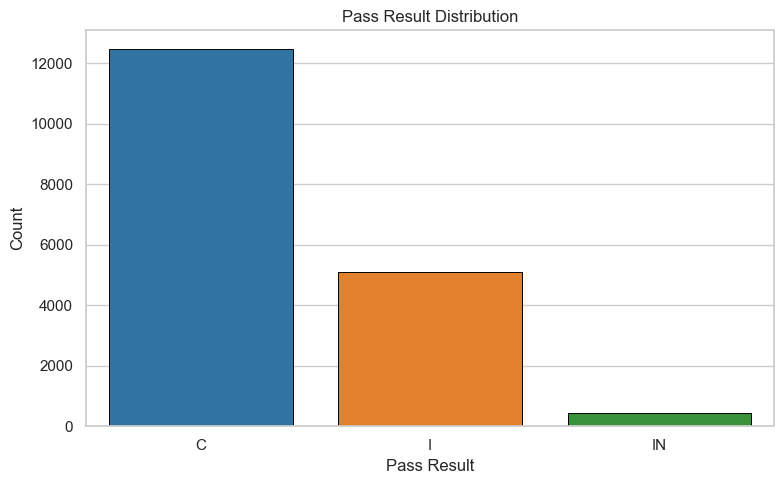

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

pass_order = sorted(supp_df["pass_result"].dropna().unique())

sns.countplot(
    data=supp_df,
    x="pass_result",
    order=pass_order,
    hue="pass_result",
    palette="tab10",
    edgecolor="black",
    linewidth=0.7,
    legend=False,
    ax=ax,
)

ax.set_title("Pass Result Distribution")
ax.set_xlabel("Pass Result")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Interpretation: Pass result distribution

Most plays in the dataset are either **completions (C)** or **incompletions (I)**, with fewer plays ending in interceptions (IN), sacks (S), or scrambles (R). This confirms that the dominant passing outcomes are completions and incompletions, while still preserving enough rarer outcomes for broader context.

In [7]:
# 7. Route of targeted receiver – frequency

route_counts = supp_df["route_of_targeted_receiver"].value_counts(dropna=False)
route_counts.head(20)

route_of_targeted_receiver
HITCH     3383
OUT       2886
FLAT      2490
CROSS     1957
GO        1776
IN        1408
SLANT     1316
POST       978
ANGLE      704
CORNER     642
SCREEN     369
WHEEL       96
NaN          4
Name: count, dtype: int64

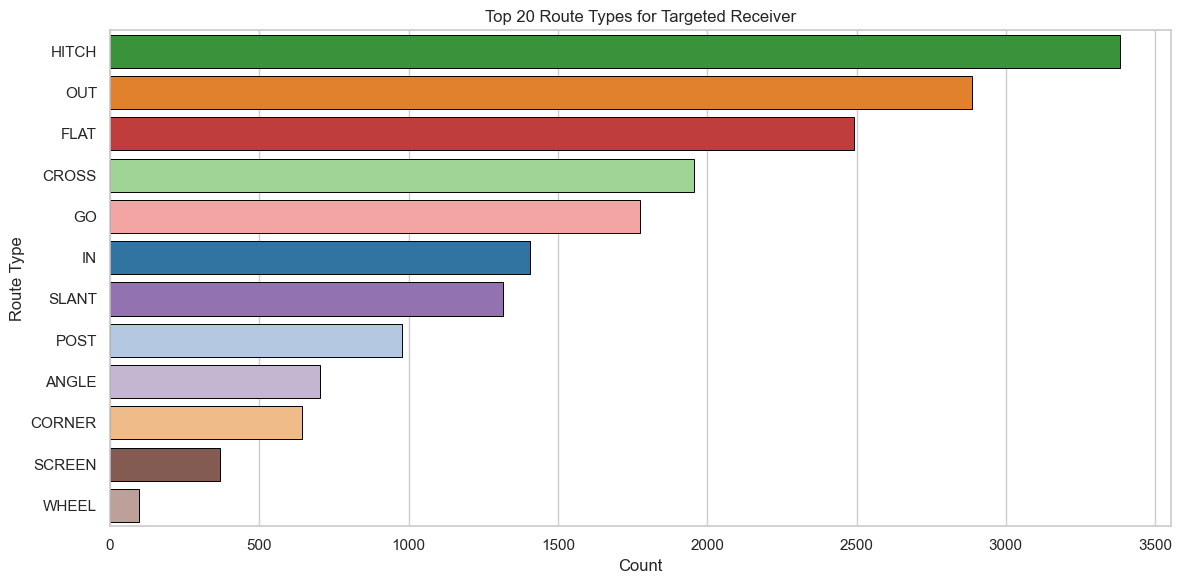

In [8]:
top_n = 20
route_counts = supp_df["route_of_targeted_receiver"].value_counts(dropna=True)

fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(
    data=supp_df[supp_df["route_of_targeted_receiver"].notna()],
    y="route_of_targeted_receiver",
    order=route_counts.head(top_n).index,
    hue="route_of_targeted_receiver",
    palette="tab20",
    edgecolor="black",
    linewidth=0.7,
    legend=False,
    ax=ax,
)

ax.set_title(f"Top {top_n} Route Types for Targeted Receiver")
ax.set_xlabel("Count")
ax.set_ylabel("Route Type")
plt.tight_layout()
plt.show()

### Interpretation: Route type distribution

The distribution of route types is clearly imbalanced. A small number of route concepts appear very frequently, whereas other routes are comparatively rare. This matters for later modeling because route categories with very small sample sizes may yield unstable estimates, while the most frequent routes are likely to dominate predictive behavior.

In [9]:
# 8. Coverage type distribution (man vs zone)

cov_counts = supp_df["team_coverage_man_zone"].value_counts(dropna=False)
cov_counts

team_coverage_man_zone
ZONE_COVERAGE    12783
MAN_COVERAGE      5221
NaN                  5
Name: count, dtype: int64

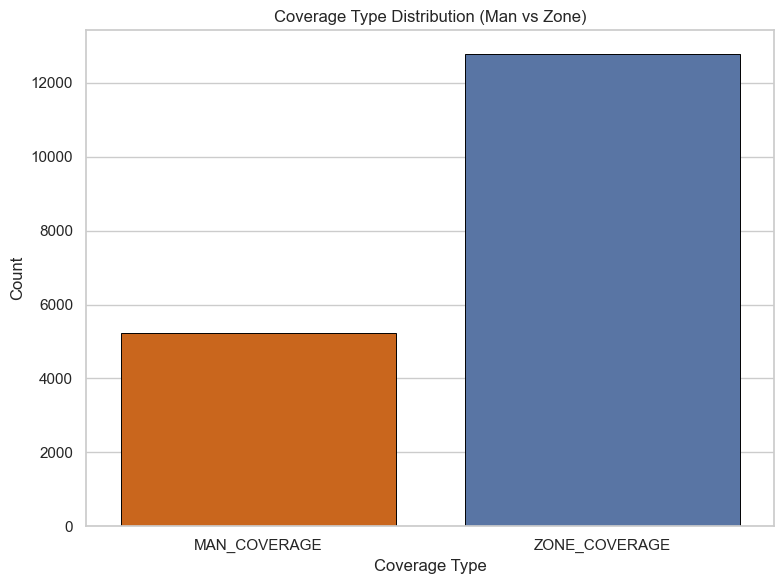

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

coverage_order = sorted(supp_df["team_coverage_man_zone"].dropna().unique())

sns.countplot(
    data=supp_df,
    x="team_coverage_man_zone",
    order=coverage_order,
    hue="team_coverage_man_zone",
    palette=[PRIMARY_BLUE, DEEP_ORANGE],
    edgecolor="black",
    linewidth=0.7,
    legend=False,
    ax=ax,
)

ax.set_title("Coverage Type Distribution (Man vs Zone)")
ax.set_xlabel("Coverage Type")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Interpretation: Coverage type distribution

Both **man** and **zone** coverage are well represented in the data, although zone coverage appears more frequently. This supports later comparison of yardage outcomes and spatial behavior under different defensive structures.

In [11]:
# 9. Continuous outcomes: yards_gained and pass_length

supp_df[["yards_gained", "pass_length"]].describe()

,yards_gained,pass_length
count,18009.000000,18009.000000
mean,8.145760,9.216947
std,9.968593,9.693004
min,-22.000000,-12.000000
25%,0.000000,3.000000
50%,6.000000,6.000000
75%,12.000000,13.000000
max,92.000000,65.000000


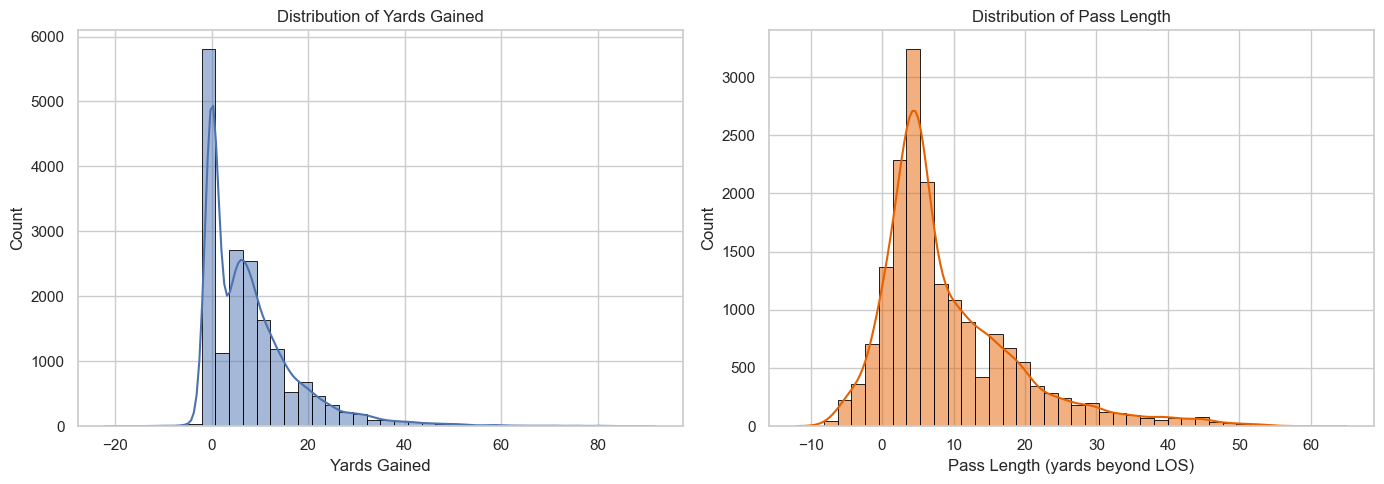

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=supp_df,
    x="yards_gained",
    bins=40,
    kde=True,
    color=PRIMARY_BLUE,
    edgecolor="black",
    linewidth=0.6,
    ax=axes[0],
)
axes[0].set_title("Distribution of Yards Gained")
axes[0].set_xlabel("Yards Gained")
axes[0].set_ylabel("Count")

sns.histplot(
    data=supp_df,
    x="pass_length",
    bins=40,
    kde=True,
    color=DEEP_ORANGE,
    edgecolor="black",
    linewidth=0.6,
    ax=axes[1],
)
axes[1].set_title("Distribution of Pass Length")
axes[1].set_xlabel("Pass Length (yards beyond LOS)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Interpretation: Yards gained and pass length

The target variable `yards_gained` is right-skewed, with many plays producing modest gains and a smaller number producing large positive outcomes. Pass length also covers a wide range, from short throws to deeper downfield attempts. These patterns motivate later use of flexible modeling approaches.

In [13]:
# 10. Basic check of tracking coordinates and player roles

input_df[["x", "y"]].describe()

,x,y
count,4.880579e+06,4.880579e+06
mean,6.050074e+01,2.681190e+01
std,2.348919e+01,1.000620e+01
min,4.100000e-01,6.200000e-01
25%,4.263000e+01,1.899000e+01
50%,6.041000e+01,2.685000e+01
75%,7.823000e+01,3.462000e+01
max,1.198600e+02,5.288000e+01


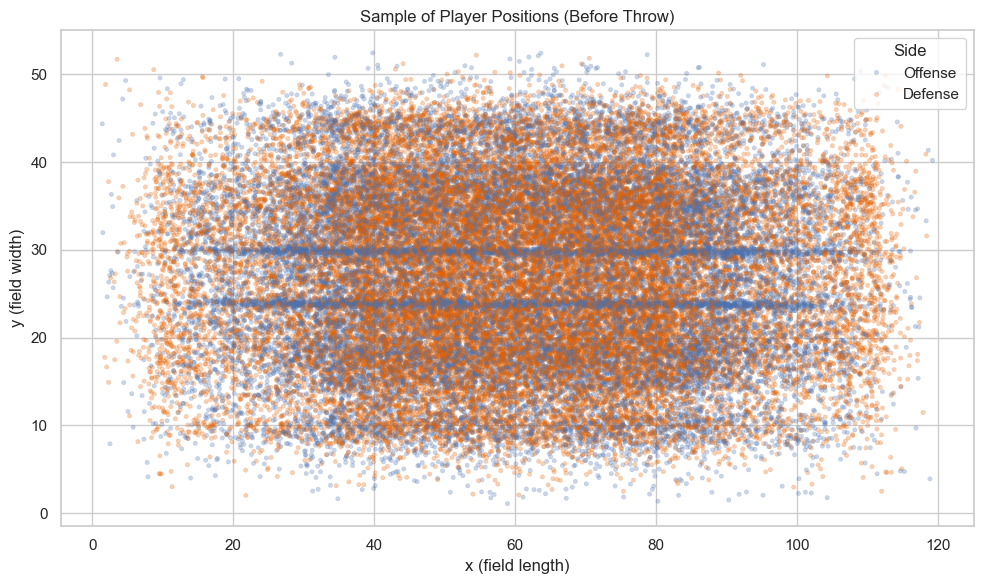

In [14]:
sample_size = min(50_000, len(input_df))
input_sample = input_df.sample(sample_size, random_state=0)

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=input_sample,
    x="x",
    y="y",
    hue="player_side",
    palette={"Offense": PRIMARY_BLUE, "Defense": DEEP_ORANGE},
    alpha=0.3,
    s=10,
    edgecolor=None,
    ax=ax,
)

ax.set_title("Sample of Player Positions (Before Throw)")
ax.set_xlabel("x (field length)")
ax.set_ylabel("y (field width)")
ax.legend(title="Side")
plt.tight_layout()
plt.show()

In [15]:
player_side_counts = input_df["player_side"].value_counts(dropna=False)
player_role_counts = input_df["player_role"].value_counts(dropna=False)

player_side_counts, player_role_counts.head(10)

(player_side
 Defense    2662657
 Offense    2217922
 Name: count, dtype: int64,
 player_role
 Defensive Coverage    2662657
 Other Route Runner    1424243
 Targeted Receiver      396914
 Passer                 396765
 Name: count, dtype: int64)

### Interpretation: Positions and roles

The coordinate ranges for `x` and `y` match expected football field dimensions, and the scatterplot confirms that offensive and defensive players occupy realistic locations prior to the throw. The role labels show that targeted receivers and defensive coverage players can be identified directly from the tracking data.

## 5. Conditional yardage patterns

In [16]:
# 11. Mean yards gained by route type (top 10 routes)

top_10_routes = supp_df["route_of_targeted_receiver"].value_counts().head(10).index

yards_by_route_top10 = (
    supp_df[supp_df["route_of_targeted_receiver"].isin(top_10_routes)]
    .groupby("route_of_targeted_receiver")["yards_gained"]
    .agg(n="count", mean="mean", std="std")
    .reset_index()
    .sort_values("mean", ascending=False)
)

yards_by_route_top10

,route_of_targeted_receiver,n,mean,std
8,POST,978,13.396728,15.605948
1,CORNER,642,11.845794,14.413643
4,GO,1776,11.532658,16.459050
2,CROSS,1957,9.051610,10.108658
6,IN,1408,8.543324,9.583411
9,SLANT,1316,7.967325,7.750167
5,HITCH,3383,7.383979,6.830685
0,ANGLE,704,6.872159,6.601704
7,OUT,2886,6.608108,6.582256
3,FLAT,2490,5.446988,6.286564


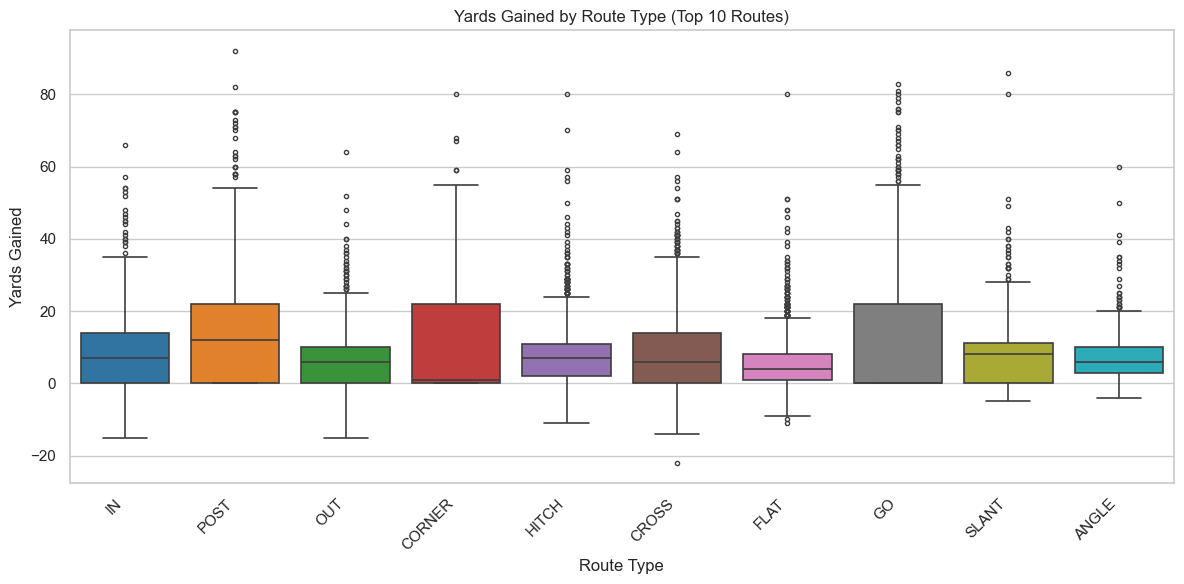

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=supp_df[supp_df["route_of_targeted_receiver"].isin(top_10_routes)],
    x="route_of_targeted_receiver",
    y="yards_gained",
    hue="route_of_targeted_receiver",
    palette="tab10",
    linewidth=1.2,
    fliersize=3,
    legend=False,
    ax=ax,
)

ax.set_title("Yards Gained by Route Type (Top 10 Routes)")
ax.set_xlabel("Route Type")
ax.set_ylabel("Yards Gained")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation: Conditional yardage by route type

Average yardage differs across route concepts. Deeper routes such as POST, CORNER, and GO tend to produce higher average gains, while shorter routes such as FLAT and HITCH generally produce smaller gains. This suggests that route design is associated with offensive effectiveness.

In [18]:
# 12. Mean yards gained by coverage scheme

yards_by_coverage = (
    supp_df.groupby("team_coverage_man_zone")["yards_gained"]
    .agg(n="count", mean="mean", std="std")
    .reset_index()
    .sort_values("mean", ascending=False)
)

yards_by_coverage

,team_coverage_man_zone,n,mean,std
1,ZONE_COVERAGE,12783,8.278182,9.694855
0,MAN_COVERAGE,5221,7.821873,10.600571


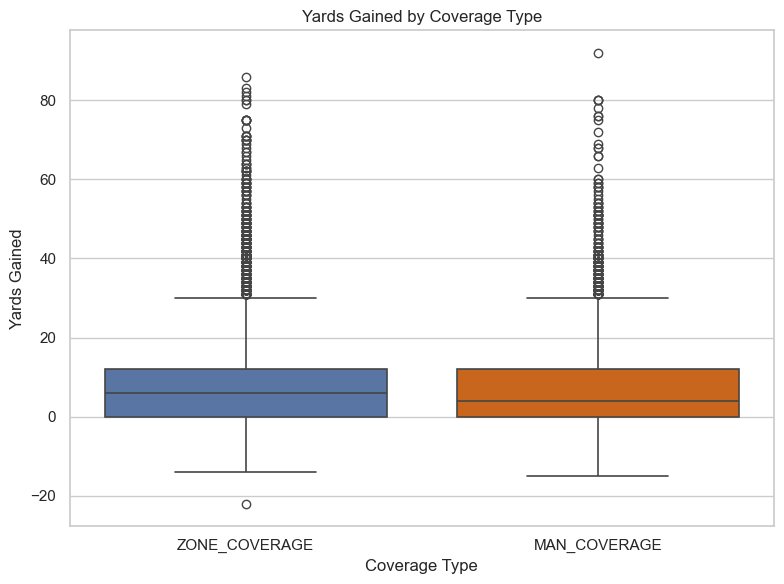

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=supp_df,
    x="team_coverage_man_zone",
    y="yards_gained",
    hue="team_coverage_man_zone",
    palette=[PRIMARY_BLUE, DEEP_ORANGE],
    linewidth=1.2,
    legend=False,
    ax=ax,
)

ax.set_title("Yards Gained by Coverage Type")
ax.set_xlabel("Coverage Type")
ax.set_ylabel("Yards Gained")
plt.tight_layout()
plt.show()

### Interpretation: Conditional yardage by coverage scheme

Mean yardage differs only modestly between man and zone coverage at the descriptive level, but the full distributions still differ in spread and central tendency. This suggests that coverage structure may influence offensive outcomes in subtle ways.

## 6. From data to research questions

The NFL Big Data Bowl 2026 dataset provides detailed information about player movement and play context during passing plays. Based on the available fields, several movement-related questions naturally arise:

- How does the **separation between the targeted receiver and nearby defenders** relate to pass success?
- Do certain **route types** consistently lead to more effective plays?
- How does **defensive coverage strategy** (man vs zone) influence receiver movement and play outcomes?
- How do **spatial and movement features** combine to explain how many yards are gained on a play?

While many questions could be explored using this dataset, it is not feasible to study all of them in depth within the scope of this project. We therefore focus on a small number of questions that are directly supported by the available data and relevant to football decision-making.

## 7. Selected research questions

After the initial exploration of the data and consideration of feasibility, we focus on the following three research questions.

### RQ1 – Separation vs Catch Outcome

> **How does the separation between the targeted receiver and the nearest defender influence pass completion?**

### RQ2 – Route Design and Play Effectiveness

> **How do different route types influence play effectiveness, measured by yards gained, and which route-related movement features are most predictive?**

### RQ3 – Defensive Coverage and Play Effectiveness

> **How do defensive coverage schemes (man vs zone) influence play effectiveness, measured by yards gained, and which coverage-related movement features are most predictive?**

Together, these questions create a coherent progression: RQ1 validates separation as a meaningful spatial feature, while RQ2 and RQ3 extend the analysis to predictive modeling of yards gained.

## 8. Constructing a Play-Level Feature Dataset

To support the research questions and subsequent predictive modeling, we construct a **play-level feature table** in which each row represents the **targeted receiver in a single passing play**.

This dataset combines information from:

- player tracking data (input tracking frames),
- contextual play information from the supplementary table,
- engineered spatial features derived from player positions.

The resulting dataset includes:

- contextual play variables (e.g., down, yards to go),
- offensive route information (e.g., `route_of_targeted_receiver`),
- defensive coverage indicators (e.g., `team_coverage_man_zone`),
- spatial features derived from tracking data, such as **receiver–defender separation**,
- the play outcome variable **`yards_gained`**, which is later used as the target variable in predictive modeling.

In addition to the play-level dataset, we also construct a **frame-level separation dataset**, where each row represents the distance between the targeted receiver and the nearest defender in a given frame prior to the throw. This dataset allows us to analyze **receiver–defender separation dynamics over time**.

In [20]:
# 13. Build and save intermediate datasets

from src.data_loading import load_merged_input_with_supp
from src.features import compute_frame_level_separation, aggregate_play_features

input_with_supp = load_merged_input_with_supp()

sep_df = compute_frame_level_separation(input_with_supp)
play_feats = aggregate_play_features(sep_df, input_with_supp)

print("Frame-level separation shape:", sep_df.shape)
print("Play-level feature table shape:", play_feats.shape)
print(play_feats.columns.tolist())

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

play_feats_path = processed_dir / "master_play_features.csv"
sep_df_path = processed_dir / "master_separation_frame_level.csv"

play_feats.to_csv(play_feats_path, index=False)
sep_df.to_csv(sep_df_path, index=False)

print("Saved:", play_feats_path)
print("Saved:", sep_df_path)

Loading: input_2023_w01.csv
Loading: input_2023_w02.csv
Loading: input_2023_w03.csv
Loading: input_2023_w04.csv
Loading: input_2023_w05.csv
Loading: input_2023_w06.csv
Loading: input_2023_w07.csv
Loading: input_2023_w08.csv
Loading: input_2023_w09.csv
Loading: input_2023_w10.csv
Loading: input_2023_w11.csv
Loading: input_2023_w12.csv
Loading: input_2023_w13.csv
Loading: input_2023_w14.csv
Loading: input_2023_w15.csv
Loading: input_2023_w16.csv
Loading: input_2023_w17.csv
Loading: input_2023_w18.csv
Tracking input shape: (4880579, 23)
Supplementary shape: (18009, 41)


/Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/src/data_loading.py:34: DtypeWarning: Columns (0: play_action) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(SUPPLEMENTARY_PATH)


Merged dataset shape: (4880579, 62)
Frame-level separation shape: (396879, 5)
Play-level feature table shape: (14107, 11)
['game_id', 'play_id', 'nfl_id_wr', 'sep_min', 'sep_mean', 'sep_at_throw', 'pass_result', 'route_of_targeted_receiver', 'team_coverage_man_zone', 'pass_length', 'yards_gained']
Saved: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/data/processed/master_play_features.csv
Saved: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/data/processed/master_separation_frame_level.csv


## 9. Export report-ready figures and tables

The following cell exports the main EDA outputs used in the report. It saves publication-ready figures to `figures/` and LaTeX-ready tables to `tables/`.

In [21]:
# 14. Export report-ready EDA figures and tables

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from pathlib import Path

# ---------------------------------------------------------
# Global plot style (publication quality)
# ---------------------------------------------------------

sns.set_style("whitegrid")
sns.set_context("talk")

DEEP_ORANGE = "#E66100"
PRIMARY_BLUE = "#4C72B0"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

# ---------------------------------------------------------
# Output folders
# ---------------------------------------------------------

FIG_DIR = PROJECT_ROOT / "figures"
TAB_DIR = PROJECT_ROOT / "tables"

FIG_DIR.mkdir(exist_ok=True, parents=True)
TAB_DIR.mkdir(exist_ok=True, parents=True)

print("Saving figures to:", FIG_DIR)
print("Saving tables  to:", TAB_DIR)


def save_table(df: pd.DataFrame, name: str, index=False):
    csv_path = TAB_DIR / f"{name}.csv"
    tex_path = TAB_DIR / f"{name}.tex"
    df.to_csv(csv_path, index=index)
    tex_path.write_text(df.to_latex(index=index, escape=True), encoding="utf-8")
    print("Saved:", csv_path.name, "and", tex_path.name)


# ---------------------------------------------------------
# Clean categorical columns
# ---------------------------------------------------------

supp_df["route_of_targeted_receiver"] = supp_df["route_of_targeted_receiver"].astype("string")
supp_df["team_coverage_man_zone"] = supp_df["team_coverage_man_zone"].astype("string")


# ---------------------------------------------------------
# 1) Yards gained distribution
# ---------------------------------------------------------

yg = supp_df["yards_gained"].dropna()

plt.figure(figsize=(10, 6))

counts, bins, _ = plt.hist(
    yg,
    bins=50,
    color=PRIMARY_BLUE,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9
)

kde = gaussian_kde(yg)
x_vals = np.linspace(yg.min(), yg.max(), 500)
bin_width = bins[1] - bins[0]

plt.plot(
    x_vals,
    kde(x_vals) * len(yg) * bin_width,
    color="#2ca02c",
    linewidth=2.5
)

plt.title("Distribution of Yards Gained")
plt.xlabel("yards_gained")
plt.ylabel("count")

plt.tight_layout()
plt.savefig(FIG_DIR / "yards_distribution.png", dpi=300)
plt.close()

print("Saved figure: yards_distribution.png")

yards_summary = pd.DataFrame({
    "Statistic": ["count", "mean", "std", "min", "25%", "50% (median)", "75%", "max"],
    "Value": [
        yg.count(), yg.mean(), yg.std(), yg.min(),
        yg.quantile(0.25), yg.median(), yg.quantile(0.75), yg.max()
    ]
})

yards_summary["Value"] = yards_summary["Value"].round(3)

save_table(yards_summary, "yards_summary")


# ---------------------------------------------------------
# 2) Route distribution
# ---------------------------------------------------------

route_counts = supp_df["route_of_targeted_receiver"].dropna().value_counts()
top_10_routes = route_counts.head(10).index

route_names = route_counts.head(10).index.astype(str)
route_vals = route_counts.head(10).values

plt.figure(figsize=(12, 6))

sns.barplot(
    x=route_names,
    y=route_vals,
    hue=route_names,
    palette="tab10",
    edgecolor="black",
    linewidth=0.7,
    legend=False
)

plt.title("Top 10 Route Types for Targeted Receiver")
plt.xlabel("route_of_targeted_receiver")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIG_DIR / "route_distribution.png", dpi=300)
plt.close()

print("Saved figure: route_distribution.png")

route_table = route_counts.head(10).reset_index()
route_table.columns = ["route_of_targeted_receiver", "count"]

save_table(route_table, "route_counts_top10")


# ---------------------------------------------------------
# 3) Coverage distribution
# ---------------------------------------------------------

cov_counts = supp_df["team_coverage_man_zone"].dropna().value_counts()

cov_names = cov_counts.index.astype(str)
cov_vals = cov_counts.values

plt.figure(figsize=(8, 6))

sns.barplot(
    x=cov_names,
    y=cov_vals,
    hue=cov_names,
    palette=[PRIMARY_BLUE, DEEP_ORANGE],
    edgecolor="black",
    linewidth=0.7,
    legend=False
)

plt.title("Coverage Type Distribution (Man vs Zone)")
plt.xlabel("team_coverage_man_zone")
plt.ylabel("count")

plt.tight_layout()
plt.savefig(FIG_DIR / "coverage_distribution.png", dpi=300)
plt.close()

print("Saved figure: coverage_distribution.png")

cov_table = cov_counts.reset_index()
cov_table.columns = ["team_coverage_man_zone", "count"]

save_table(cov_table, "coverage_counts")


# ---------------------------------------------------------
# 4) Route boxplot
# ---------------------------------------------------------

route_df = supp_df.dropna(subset=["route_of_targeted_receiver", "yards_gained"])

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=route_df[route_df["route_of_targeted_receiver"].isin(top_10_routes)],
    x="route_of_targeted_receiver",
    y="yards_gained",
    hue="route_of_targeted_receiver",
    palette="tab10",
    linewidth=1.2,
    fliersize=3,
    legend=False
)

plt.title("Yards Gained by Route Type (Top 10 Routes)")
plt.xlabel("Route Type")
plt.ylabel("Yards Gained")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_route_boxplot.png", dpi=300)
plt.close()

print("Saved figure: fig6_route_boxplot.png")


# ---------------------------------------------------------
# 5) Coverage boxplot
# ---------------------------------------------------------

cov_df = supp_df.dropna(subset=["team_coverage_man_zone", "yards_gained"])

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=cov_df,
    x="team_coverage_man_zone",
    y="yards_gained",
    hue="team_coverage_man_zone",
    palette=[PRIMARY_BLUE, DEEP_ORANGE],
    linewidth=1.2,
    legend=False
)

plt.title("Yards Gained by Coverage Type")
plt.xlabel("Coverage Type")
plt.ylabel("Yards Gained")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_coverage_boxplot.png", dpi=300)
plt.close()

print("Saved figure: fig6_coverage_boxplot.png")




print("\n✅ Export complete.")

Saving figures to: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/figures
Saving tables  to: /Users/siamsadman/Git_Projects/git-projects/statistical_consulting_project/nfl_big_data_bowl_2026/nfl-yards-gained-prediction/tables
Saved figure: yards_distribution.png
Saved: yards_summary.csv and yards_summary.tex
Saved figure: route_distribution.png
Saved: route_counts_top10.csv and route_counts_top10.tex
Saved figure: coverage_distribution.png
Saved: coverage_counts.csv and coverage_counts.tex
Saved figure: fig6_route_boxplot.png
Saved figure: fig6_coverage_boxplot.png

✅ Export complete.


## 10. Summary of this notebook

In this notebook, we:

- loaded and inspected the main tracking and supplementary datasets,
- confirmed the structure and role of each dataset,
- performed exploratory analysis on outcomes, route types, coverage schemes, and key continuous variables,
- examined conditional yardage patterns by route and coverage,
- motivated the final research questions guiding the analysis, and
- constructed the initial **play-level feature dataset** and **frame-level separation dataset** used in later notebooks.

The play-level dataset aggregates spatial and contextual information for each targeted receiver in a pass play, while the frame-level dataset preserves receiver–defender separation across pre-throw frames for temporal analysis.

### Next steps

- **`02_rq1_separation_vs_catch.ipynb`** — validation of separation as a spatial metric associated with pass completion  
- **`03_feature_engineering.ipynb`** — construction of the final modeling feature table  
- **`04_predictive_modeling_yards_gained.ipynb`** — predictive modeling and evaluation of yards gained